# 01 - EDA de comparacion entre empresas

Este notebook explora el **foco 2: comparacion por empresa / manufacturer**.
La idea es validar que el dataset realmente permite responder preguntas como:

- que empresas concentran mas medicamentos;
- que fabricantes tienen mejor reputacion promedio;
- que tan estable es la calidad dentro de una misma empresa;
- cuantas composiciones se repiten en varias empresas;
- si vale la pena avanzar a un analisis comparativo mas profundo.

In [17]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd

from src.load_data import load_medicine_data
from src.enfoque_02_comparacion_empresas.cleaning import clean_company_comparison_data
from src.enfoque_02_comparacion_empresas.analysis import plot_correlation_size_vs_good_reviews
from src.enfoque_02_comparacion_empresas.validation import full_quality_report

plt.style.use("default")
pd.set_option("display.max_colwidth", 120)


df_raw = load_medicine_data(download_if_missing=False)
report = full_quality_report(df_raw)
df = clean_company_comparison_data(df_raw, save=False)

print(f"Dataset raw: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"Dataset para foco 2: {df.shape[0]:,} filas x {df.shape[1]} columnas")

ImportError: cannot import name 'plot_correlation_size_vs_good_reviews' from 'src.enfoque_02_comparacion_empresas.analysis' (C:\Users\cesar\OneDrive\Desktop\DuocUC\SCY1101-Exp1-Drug-Data-Analysis\src\enfoque_02_comparacion_empresas\analysis.py)

## 1. Calidad base del dataset

Antes de comparar empresas, verificamos si `Manufacturer`, `Composition` y las
columnas de review tienen problemas obvios que puedan sesgar el analisis.

In [18]:
report

{'shape': (11825, 9),
 'duplicates': 84,
 'manufacturer_blank': 0,
 'composition_blank': 0,
 'review_inconsistencies': 0,
 'manufacturer_unique': 759,
 'null_summary': {'Medicine Name': 0,
  'Composition': 0,
  'Uses': 0,
  'Side_effects': 0,
  'Manufacturer': 0,
  'Excellent Review %': 0,
  'Average Review %': 0,
  'Poor Review %': 0}}

## 2. Estructura de `Manufacturer`

El primer cuello de botella del foco 2 es la cardinalidad: si casi todas las
empresas tienen 1 o 2 medicamentos, los rankings podrian ser inestables.

In [ ]:
manufacturer_counts = df["manufacturer_clean"].value_counts()

resumen_empresas = pd.Series({
    "empresas_unicas": int(manufacturer_counts.shape[0]),
    "mediana_medicamentos_por_empresa": float(manufacturer_counts.median()),
    "empresas_con_5_o_mas": int((manufacturer_counts >= 5).sum()),
    "empresas_con_10_o_mas": int((manufacturer_counts >= 10).sum()),
    "empresas_con_20_o_mas": int((manufacturer_counts >= 20).sum()),
})

resumen_empresas

empresas_unicas                     759.0
mediana_medicamentos_por_empresa      2.0
empresas_con_5_o_mas                238.0
empresas_con_10_o_mas               150.0
empresas_con_20_o_mas                90.0
dtype: float64

In [ ]:
top_empresas = manufacturer_counts.head(15).rename_axis("manufacturer_clean").reset_index(name="n_medicines")
top_empresas

,manufacturer_clean,n_medicines
0,Sun Pharmaceutical Industries Ltd,819
1,Intas Pharmaceuticals Ltd,648
2,Cipla Ltd,569
3,Torrent Pharmaceuticals Ltd,441
4,Lupin Ltd,432
5,Mankind Pharma Ltd,336
6,Zydus Cadila,326
7,Alkem Laboratories Ltd,325
8,Macleods Pharmaceuticals Pvt Ltd,316
9,Abbott,279


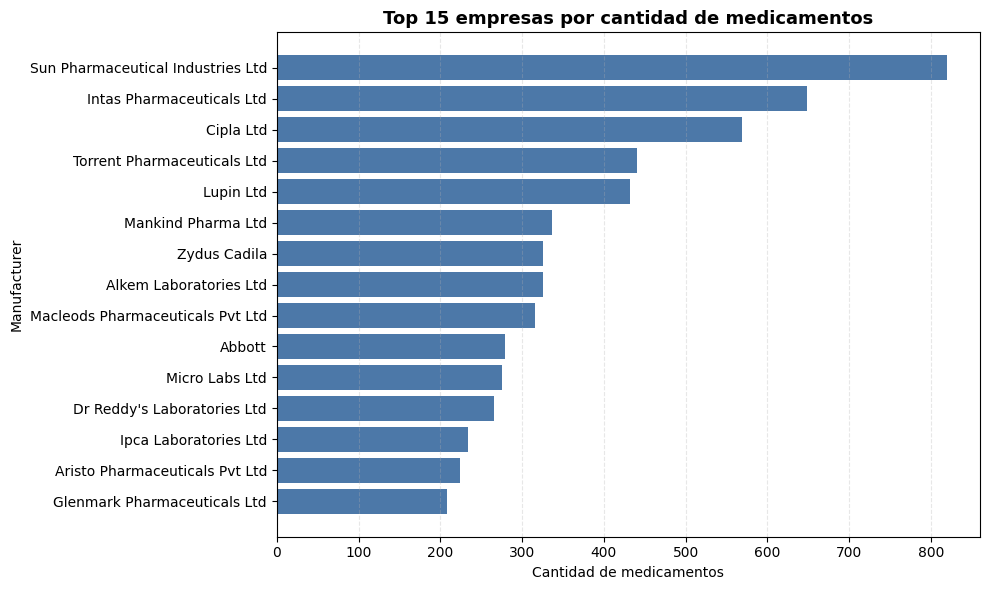

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_empresas["manufacturer_clean"][::-1], top_empresas["n_medicines"][::-1], color="#4C78A8")
ax.set_title("Top 15 empresas por cantidad de medicamentos", fontsize=13, fontweight="bold")
ax.set_xlabel("Cantidad de medicamentos")
ax.set_ylabel("Manufacturer")
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Reviews por empresa: vista preliminar

Para no confundir volumen con calidad, miramos la mezcla de reviews y una
primera variable sintetica: `review_balance = Excellent - Poor`.

In [ ]:
df[["Excellent Review %", "Average Review %", "Poor Review %", "review_balance"]].describe().round(2)

,Excellent Review %,Average Review %,Poor Review %,review_balance
count,11741.00,11741.00,11741.00,11741.00
mean,38.51,35.78,25.71,12.79
std,25.19,18.26,23.95,45.64
min,0.00,0.00,0.00,-100.00
25%,22.00,27.00,0.00,-12.00
50%,34.00,35.00,22.00,13.00
75%,51.00,47.00,35.00,42.00
max,100.00,88.00,100.00,100.00


In [ ]:
ranking_preliminar = (
    df.groupby("manufacturer_clean", as_index=False)
      .agg(
          n_medicines=("Medicine Name", "count"),
          excellent_mean=("Excellent Review %", "mean"),
          poor_mean=("Poor Review %", "mean"),
          review_balance_mean=("review_balance", "mean"),
      )
)
ranking_preliminar = ranking_preliminar[ranking_preliminar["n_medicines"] >= 10]
ranking_preliminar = ranking_preliminar.sort_values("review_balance_mean", ascending=False)
ranking_preliminar.head(10).round(2)

,manufacturer_clean,n_medicines,excellent_mean,poor_mean,review_balance_mean
74,AstraZeneca,21,57.52,11.81,45.71
339,Jubilant Life Sciences,15,55.20,15.73,39.47
216,Eli Lilly and Company India Pvt Ltd,18,45.94,11.06,34.89
437,Merck Ltd,22,47.68,13.59,34.09
474,Novartis India Ltd,41,47.41,13.66,33.76
188,Dios Lifesciences Pvt Ltd,11,54.64,21.18,33.45
57,Aprica Pharmaceuticals Pvt Ltd,12,52.58,20.08,32.50
127,Boehringer Ingelheim,13,42.31,10.23,32.08
509,Panacea Biotec Ltd,33,45.76,15.64,30.12
463,Neon Laboratories Ltd,23,46.74,16.78,29.96


C:\Users\cesar\AppData\Local\Temp\ipykernel_109452\2389362323.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=order, patch_artist=True)


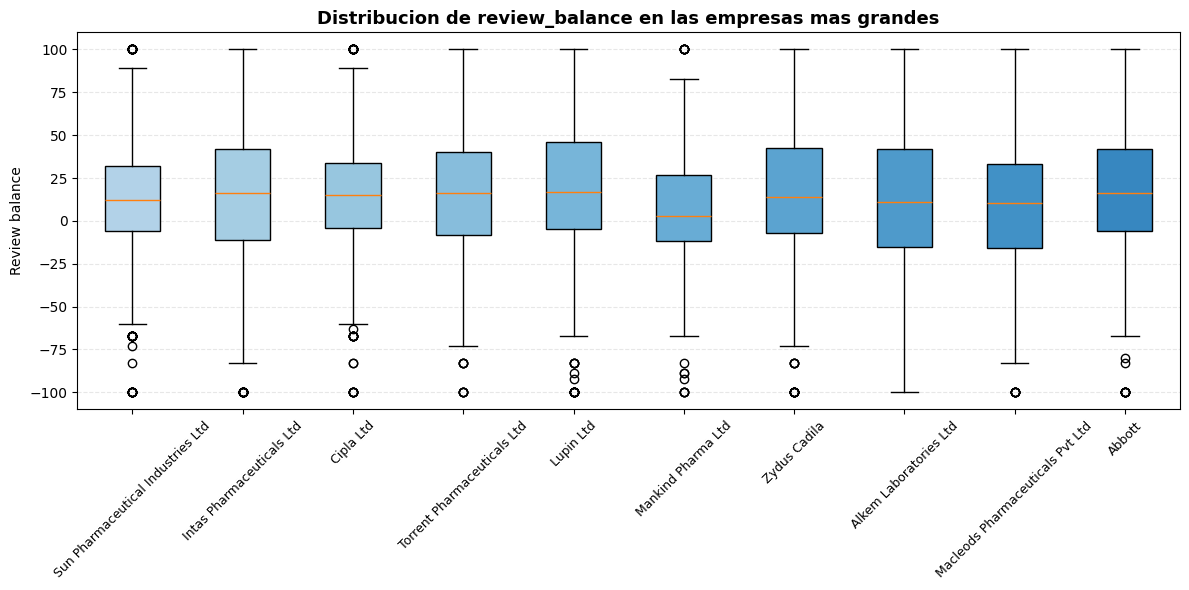

In [ ]:
top_boxplot = manufacturer_counts.head(10).index
box_df = df[df["manufacturer_clean"].isin(top_boxplot)]
order = box_df["manufacturer_clean"].value_counts().index.tolist()
groups = [box_df.loc[box_df["manufacturer_clean"] == name, "review_balance"].values for name in order]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(groups, labels=order, patch_artist=True)
for patch, color in zip(bp["boxes"], plt.cm.Blues(range(80, 80 + 10 * len(groups), 10))):
    patch.set_facecolor(color)
ax.set_title("Distribucion de review_balance en las empresas mas grandes", fontsize=13, fontweight="bold")
ax.set_ylabel("Review balance")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### Correlacion entre volumen y reviews buenas

Aqui medimos si las empresas con mas medicamentos en el dataset tienden
a tener un mayor porcentaje promedio de `Excellent Review %`.


In [ ]:
pearson_corr = ranking_preliminar["n_medicines"].corr(ranking_preliminar["excellent_mean"])
print(f"Correlacion de Pearson entre cantidad de medicamentos y Excellent Review % promedio: {pearson_corr:.3f}")

plot_correlation_size_vs_good_reviews(df, min_medicines=10)
plt.show()


Correlacion de Pearson entre cantidad de medicamentos y Excellent Review % promedio: 0.019


NameError: name 'plot_correlation_size_vs_good_reviews' is not defined

## 4. Misma composicion en varias empresas

Este es el punto mas fuerte del foco 2. Si la misma composicion aparece en mas

 de un fabricante, ya tenemos base para comparar calidad entre empresas sin
mezclar medicamentos totalmente distintos.

In [ ]:
composition_company_counts = df.groupby("composition_key")["manufacturer_clean"].nunique().sort_values(ascending=False)

pd.Series({
    "composiciones_unicas": int(df["composition_key"].nunique()),
    "composiciones_presentes_en_2_o_mas_empresas": int((composition_company_counts >= 2).sum()),
    "composiciones_presentes_en_3_o_mas_empresas": int((composition_company_counts >= 3).sum()),
    "maximo_de_empresas_para_una_misma_composicion": int(composition_company_counts.max()),
})

composiciones_unicas                             1627
composiciones_presentes_en_2_o_mas_empresas       940
composiciones_presentes_en_3_o_mas_empresas       660
maximo_de_empresas_para_una_misma_composicion      68
dtype: int64

In [ ]:
ejemplos_multiempresa = (
    df.groupby("composition_key")
      .agg(
          n_empresas=("manufacturer_clean", "nunique"),
          n_medicamentos=("Medicine Name", "count"),
          empresas=("manufacturer_clean", lambda s: ", ".join(sorted(set(s))[:5])),
      )
      .query("n_empresas >= 3")
      .sort_values(["n_empresas", "n_medicamentos"], ascending=False)
      .head(10)
)

ejemplos_multiempresa

,n_empresas,n_medicamentos,empresas
composition_key,,,
Levocetirizine + Montelukast,68,113,"Adley Formulations, Albert David Ltd, Alembic Pharmaceuticals Ltd, Alkem Laboratories Ltd, Alna Biotech Pvt Ltd"
Ketoconazole,68,111,"A. Menarini India Pvt Ltd, Ajanta Pharma Ltd, Alniche Life Sciences Pvt Ltd, Ampra Pharmaceuticals, Amwill Healthcare"
Itraconazole,57,119,"Abbott, Acme Generics LLP, Adroit Biomed Ltd, Alembic Pharmaceuticals Ltd, Algen Healthcare Limited"
Domperidone + Rabeprazole,53,67,"Abbott, Alembic Pharmaceuticals Ltd, Alkem Laboratories Ltd, Apotex Pharmachem India Pvt Ltd, Aristo Pharmaceuticals..."
Glimepiride + Metformin,52,173,"AN Pharmaceuticals Pvt Ltd, Abbott, Akumentis Healthcare Ltd, Alembic Pharmaceuticals Ltd, Alkem Laboratories Ltd"
Luliconazole,50,118,"A. Menarini India Pvt Ltd, Abbott, Ajanta Pharma Ltd, Alkem Laboratories Ltd, Apex Laboratories Pvt Ltd"
Telmisartan,49,95,"Abbott, Acmedix Pharma LLP, Alembic Pharmaceuticals Ltd, Alkem Laboratories Ltd, Aprica Pharmaceuticals Pvt Ltd"
Domperidone + Pantoprazole,49,62,"AN Pharmaceuticals Pvt Ltd, Aareen Healthcare Pvt Ltd, Abbott, Alembic Pharmaceuticals Ltd, Alkem Laboratories Ltd"
Paracetamol,45,97,"Abbott, Aksigen Hospital Care, Albia Biocare, Alembic Pharmaceuticals Ltd, Alkem Laboratories Ltd"


## 5. Side effects y especializacion terapeutica

El foco 2 no es solo ranking. Tambien necesitamos ver si algunas empresas se
concentran en medicamentos con mas efectos secundarios o en ciertos nichos
terapeuticos.

In [ ]:
df[["n_side_effects", "n_components"]].describe().round(2)

,n_side_effects,n_components
count,11741.00,11741.00
mean,6.92,1.53
std,4.31,0.77
min,1.00,1.00
25%,4.00,1.00
50%,6.00,1.00
75%,9.00,2.00
max,36.00,9.00


In [ ]:
therapeutic_mix = (
    df["therapeutic_areas"]
      .explode()
      .value_counts()
      .rename_axis("therapeutic_area")
      .reset_index(name="n_medicines")
)
therapeutic_mix.head(12)

,therapeutic_area,n_medicines
0,Other,2265
1,Infections,1985
2,Cardiovascular,1880
3,Pain / Inflammation,1753
4,Dermatology,1276
5,Diabetes / Endocrine,1141
6,Neurology / Mental Health,1122
7,Respiratory / Allergy,886
8,Gastrointestinal,762
9,Eye / ENT,665


## 6. Conclusiones del EDA

- El foco 2 es viable porque hay suficiente volumen para comparar empresas grandes.
- `Manufacturer` tiene alta cardinalidad, por lo que conviene usar filtros minimos de volumen.
- Existen muchas composiciones repetidas entre empresas, lo que habilita la comparacion mas potente del dataset.
- `Uses` viene muy sucio para una segmentacion exacta; conviene transformarlo a areas terapeuticas.
- `Side_effects` y `review_balance` ya permiten cruzar reputacion con seguridad en el analisis final.